<!-- # <span style="color:red">UNDER CONSTRUCTION!!!!</span> -->

# Spoken Language Processing - Instituto Superior Técnico
## Laboratory Assignment 2 - Native Language Identification challenge

# WEEK 2 - Using pre-trained models


During this week, students will implement two modern systems for native language identification based on:
- speaker representations (utterance-based) obtained with an x-vector model (this notebook); 
- speech representations (frame-based) obtained with a self-supervised learning (SSL) pre-trained model (`lab2_ssl.ipynb` notebook). 

In both cases, students are encouraged to explore different feature configurations and alternative downstream models.

## Before starting

Let's import some modules and make some definitions:

In [1]:
from pf_tools import CheckThisCell

In [2]:
import os 
import csv 
import pickle
import numpy as np
import librosa 
import torch 

from pf_tools import CheckThisCell, ETS
from speechbrain.inference.classifiers import EncoderClassifier
from speechbrain.utils.data_utils import split_path
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

LANGUAGES = ('ARA',  'KOR',  'SPA',  'TUR')
LANG2ID = {'ARA':0, 'KOR':1, 'SPA':2, 'TUR':3}
ID2LANG = dict((LANG2ID[k],k)for k in LANG2ID)

/Users/daniel/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Like in the previous Notebooks, you need to mount Google drive if you are working on Google Colab. Otherwise, you should skip or delete the following code cell:


Like in week1, the audio data is expected to be in a folder with the following format:

```
ets_data/
├── train/
│   └── audio/
│       └──wav files
│   └── key.lst 
│
└── train100/
    └── audio/
        └──wav files
    └── key.lst
... 
```

You must already have this from the previous week, so you can set-up your data directory:

In [3]:
CWD = os.getcwd()
DATADIR = f'{CWD}/ets_data/' # <--- Change this variable to your working directory containig the ETS data
if not os.path.isdir(DATADIR):
    os.mkdir(DATADIR)
    print(f'WARNING: Your data is not in the folder {DATADIR}')

os.chdir(CWD)
print(f'Your ETS data should be in this folder {DATADIR}')


Your ETS data should be in this folder /Users/daniel/Documents/Unidokumente/Repository/SLP_Lab2_New/SLP2/ets_data/


If you need to download again the data, you can run the following cell:

In [ ]:
raise CheckThisCell

os.chdir(DATADIR)

# download train
!wget http://groups.tecnico.ulisboa.pt/speechproc/pf25/lab2/train.tgz
!tar -xzvf train.tgz

#download train100
!wget http://groups.tecnico.ulisboa.pt/speechproc/pf25/lab2/train100.tgz
!tar -xzvf train100.tgz

#download dev
!wget http://groups.tecnico.ulisboa.pt/speechproc/pf25/lab2/dev.tgz
!tar -xzvf dev.tgz

#download evl
!wget http://groups.tecnico.ulisboa.pt/speechproc/pf25/lab2/evl.tgz
!tar -xzvf evl.tgz

os.chdir(CWD)

## Using pre-trained speaker embeddings (x-vectors)

The goal of this part of the lab is to get familiar with and show how to use pre-trained speaker embedings (a.k.a. x-vectors) for speech classification tasks.

There exist plenty of resources and pre-trained models that can be  useful for our task. In particular, x-vectors are the current state of the art approach to obtain speech embeddings that characterize very efficiently speaker or language, among others. X-vectors are neural models typically trained for speaker identification in a supervised way, but also in some cases for other related tasks, like language recognition. Once trained, they can be used to obtain a single embedding vector of fixed dimension for each audio input. This vector corresponds to the activations of one of the layers after the pooling layer. 

The following are examples of x-vector models available in the `speechbrain` module: 

- `speechbrain/spkrec-ecapa-voxceleb`: trained using a large speaker corpus for speaker verification: https://huggingface.co/speechbrain/spkrec-ecapa-voxceleb

- `speechbrain/lang-id-voxlingua107-ecapa`: trained using a large corpus of 107 languages for language identification: https://huggingface.co/speechbrain/lang-id-voxlingua107-ecapa

- `speechbrain/lang-id-commonlanguage_ecapa`: trained using a large corpus of 45 languages for language identification: https://huggingface.co/speechbrain/lang-id-commonlanguage_ecapa


The following code cell shows how to import one of those models to obtain an embedding vector:

In [4]:

xvector_model = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir=f"{CWD}/tmp")

signal = xvector_model.load_audio(f'{DATADIR}/train100/audio/train_0003.wav')
emb =  xvector_model.encode_batch(signal)

print(type(emb), emb.shape)

[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


<class 'torch.Tensor'> torch.Size([1, 1, 192])


These (very informative) embedding vectors can be used to train simple models for several speech classification tasks, achieving excellent results. In particular, in this lab assignment, we will train a simple linear SVM on top of these x-vectors. 


Student groups will be graded depending on their ability to explore different feature configurations and model alternatives/configurations.

### 1. Extracting x-vectors for the ETS datasets

Just like in Part1, we will code the feature transformation to process all data and obtain x-vectors. In this case, the function should receive as arguments the audio filename and an instance of `EncoderClassifier` (the x-vector model) and return the numpy array with the features. You must complete the following code using the previous example:

In [10]:
from speechbrain.dataio.dataio import read_audio
# This function receives a filename and one encoder model 
# (for instance, xvector_model object in previous cell example) and returns 
# the extracted x-vectors as a numpy array of shape (1, embedding_dimension).
# Notice that the encoder extractor module generates a softlink to each audio 
# file. To avoid generating "junk", you can delete this link also in the
# function 

def extract_xvec(filename, emb_model):
   # Load audio file
    signal = read_audio(filename)  # returns a Torch tensor

    # Ensure it's a batch with shape (1, time)
    signal = signal.unsqueeze(0)

    # Encode to get x-vector
    embedding = emb_model.encode_batch(signal)

    # Convert to numpy and get shape (1, embedding_dim)
    embedding = embedding.squeeze(0).cpu().numpy()
    
    # Remove the "annoying" soft-link
    _, fl = split_path(filename)
    if os.path.islink(fl):
        os.remove(fl)
    return embedding

# This must return a numpy array of shape (1,192). 
# The 192 may depend on the specific model
emb = extract_xvec(f'{DATADIR}/train100/audio/train_0003.wav' , xvector_model)

# Check that this shape and type
# it shoulb ebe: (1, 192) <class 'numpy.ndarray'>
print(emb.shape, type(emb))

(1, 192) <class 'numpy.ndarray'>


Let's generate the x-vectors for all our data sets using the ETS class and store in disk. Like in Part 1, we can keep different transformation configurations in a dictionary for later usage.  

Let's define first our configurations (you can try to different x-vector models, the propsed ones or even other that you may find in huggingface):

In [12]:

#raise CheckThisCell ## <---- Remove this after completing/checking this cell

transform = { 
                'spkrec-ecapa-voxceleb' : # <--- You chan look for different models in speechbrain
                {
                    'audio_transform': 
                        lambda x : extract_xvec(x, 
                            emb_model = EncoderClassifier.from_hparams(
                                        source="speechbrain/spkrec-ecapa-voxceleb", # <--- You chan look for different models in speechbrain
                                        savedir=f"{CWD}/tmp/spkrec-ecapa-voxceleb"
                                        )
                            ), ## <--- You need to modify this here
                    'chunk_transform': None,
                    'chunk_size': 0,
                    'chunk_hop':0   
                }
            }

transform['lang-id-voxlingua107-ecapa'] = {
                    'audio_transform': 
                        lambda x : extract_xvec(x, 
                            emb_model = EncoderClassifier.from_hparams(
                                        source="speechbrain/lang-id-voxlingua107-ecapa", # <--- You chan look for different models in speechbrain
                                        savedir=f"{CWD}/tmp/lang-id-voxlingua107-ecapa"
                                        )
                            ), ## <--- You need to modify this here
                    'chunk_transform': None,
                    'chunk_size': 0,
                    'chunk_hop':0   
                }


And now let's do feature extraction. Be patient because this process can be a bit slow depending on the resources of your machine:

In [13]:

#raise CheckThisCell ## <---- Remove this after completing/checking this cell

# Download and feature extract
trainset = 'train100'
transform_id = 'spkrec-ecapa-voxceleb' 

ets_partitions = {}
# for partition in ('train', 'train100', 'dev', 'evl'):
for partition in ('train100', 'dev', 'evl'):
    ets_partitions[partition] = ETS(DATADIR, partition, 
                    transform_id=transform_id, 
                    audio_transform=transform[transform_id]['audio_transform'], 
                    chunk_transform=transform[transform_id]['chunk_transform'],
                    chunk_size=transform[transform_id]['chunk_size'], 
                    chunk_hop=transform[transform_id]['chunk_hop']
                    )


100%|██████████| 400/400 [15:06<00:00,  2.27s/it]
100%|██████████| 226M/226M [00:17<00:00, 13.7MB/s] 
100%|██████████| 186/186 [08:58<00:00,  2.89s/it]
100%|██████████| 226M/226M [00:15<00:00, 15.1MB/s] 
100%|██████████| 185/185 [09:23<00:00,  3.05s/it]


### 2. Training an SVM model 

Our first attempt of native language identification system based on x-vectors will be a simple SVM model (4-classes) like in the `openSMILE` baseline, but in this case we will be using x-vectors as features. 

First, we will use the ETS data instances to store the x-vectors, the labels and file identifiers in numpy arrays:

In [14]:
from pf_tools import prepare_ets_data

#   Concatenate all data and labels
#   Each row corresponds to a file
#   We store the data, labels and file identifiers of each partition in dictionaries 
#     with the partition name as key

data, labels, fileids = {}, {}, {}
# for partition in ('train', 'train100', 'dev', 'evl'):
for partition in ('train100', 'dev', 'evl'):
    data_and_labels = prepare_ets_data(ets_partitions[partition])
    print(f'Partition: {partition}')
    print(f'Number of samples: {data_and_labels["data"].shape[0]}')
    print(f'Number of features: {data_and_labels["data"].shape[1]}')
    print(f'Number of labels: {len(np.unique(data_and_labels["label"]))}')
    print(f'Number of identifiers (samples): {len(np.unique(data_and_labels["identifiers"]))}')
    print('---')
    data[partition] = data_and_labels['data']
    labels[partition] = data_and_labels['label']
    fileids[partition] = data_and_labels['identifiers']
    

Partition: train100
Number of samples: 400
Number of features: 192
Number of labels: 4
Number of identifiers (samples): 400
---
Partition: dev
Number of samples: 186
Number of features: 192
Number of labels: 4
Number of identifiers (samples): 186
---
Partition: evl
Number of samples: 185
Number of features: 192
Number of labels: 1
Number of identifiers (samples): 185
---


Now, we will use `sklearn` linear SVM to: 
1. Train our classifier and save it for later use.
2. Predict on the dev and evl partitions and save the results

In [15]:
from sklearn.svm import LinearSVC
from pf_tools import save_model

trainset = 'train100'

# Train a linear SVM
model = LinearSVC() ### <---- a linear SVM
model.fit(data[trainset], labels[trainset])  ## <---- train MODEL

model_id = save_model(model, f'svm_{transform_id}', f'{DATADIR}/{trainset}/models/')
print(f'Model {model_id} saved in {DATADIR}/{trainset}/models/')

# Predict the dev and evl sets
dev_results = model.predict(data['dev']) #  Predict dev
filename = f'{DATADIR}/{trainset}/models/{model_id}/dev.pkl'
pickle.dump({'hyp':dev_results, 'fileids':fileids['dev']}, open(filename, 'wb'))

evl_results = model.predict(data['evl']) #  Predict evl
filename = f'{DATADIR}/{trainset}/models/{model_id}/evl.pkl'
pickle.dump({'hyp':evl_results, 'fileids':fileids['evl']}, open(filename, 'wb'))


Model saved to /Users/daniel/Documents/Unidokumente/Repository/SLP_Lab2_New/SLP2/ets_data//train100/models//svm_spkrec-ecapa-voxceleb_2025-05-25_12:53:41/model.pkl
Model svm_spkrec-ecapa-voxceleb_2025-05-25_12:53:41 saved in /Users/daniel/Documents/Unidokumente/Repository/SLP_Lab2_New/SLP2/ets_data//train100/models/


It should be extremely easy to experiment other models provided in the `sklearn` module, including SVMs with other kernels, Random Forests, etc.


#### 2.1 Analyze results on the dev set and prepare your submission file

Let's check our performance on the dev set:

              precision    recall  f1-score   support

         ARA       0.58      0.54      0.56        46
         KOR       0.76      0.80      0.78        46
         SPA       0.81      0.73      0.77        52
         TUR       0.60      0.67      0.63        42

    accuracy                           0.69       186
   macro avg       0.69      0.69      0.68       186
weighted avg       0.69      0.69      0.69       186

0.6881720430107527


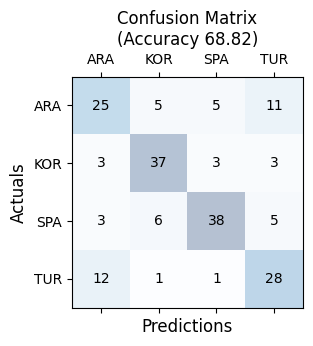

In [16]:
from pf_tools import plot_confusion_matrix
ref, hyp = labels['dev'], dev_results
print(classification_report(ref, hyp))
print(accuracy_score(ref, hyp))
cm = confusion_matrix(ref, hyp)
plot_confusion_matrix(cm, LANGUAGES, title=f'Confusion Matrix\n(Accuracy {100*accuracy_score(ref, hyp):.2f})')


And generate the final prediction file and make a submission to the  [Kaggle competition](https://www.kaggle.com/t/312cd4200cfb4e138ea9372ce5bc33fd):

In [22]:
from pf_tools import create_submission_file

students_group = '21' # <--- CHANGE THIS ACCORDINGLY

model_id = 'svm_spkrec-ecapa-voxceleb_2025-05-04_19:10:21'
model_id_short = 'svm_spkrec-ecapa'

results_path = f'{DATADIR}/{trainset}/models/{model_id}/'
filename = f'{CWD}/g{students_group}_{trainset}_{model_id_short}.csv' # <--- CHANGE THIS ACCORDINGLY
print(filename)
create_submission_file(results_path, filename, lang2id=LANG2ID)


/Users/daniel/Documents/Unidokumente/Repository/SLP_Lab2_New/SLP2/g21_train100_svm_spkrec-ecapa.csv


FileNotFoundError: [Errno 2] No such file or directory: '/Users/daniel/Documents/Unidokumente/Repository/SLP_Lab2_New/SLP2/ets_data//train100/models/svm_spkrec-ecapa-voxceleb_2025-05-04_19:10:21//dev.pkl'

If things went as expected, you should around 68.8% accuracy result.

At this point, you can explore different x-vector model configurations for feature extraction and alternative models to the linear SVM.

### 3. Training a neural network model 

As an alternative to the linear SVM, we will explore simple neural models on top of x-vector features. 
Let's first instanciate the ETS objects for all the partitions with the desired configuration as usual:

In [23]:

#raise CheckThisCell ## <---- Remove this after completing/checking this cell

# Download and feature extract
trainset = 'train100'
transform_id = 'spkrec-ecapa-voxceleb' # <--- You can change this to 'lang-id-voxlingua107-ecapa' to use the other model

ets_partitions = {}
# for partition in ('train', 'train100', 'dev', 'evl'):
for partition in ('train100', 'dev', 'evl'):
    ets_partitions[partition] = ETS(DATADIR, partition, 
                    transform_id=transform_id, 
                    audio_transform=transform[transform_id]['audio_transform'], 
                    chunk_transform=transform[transform_id]['chunk_transform'],
                    chunk_size=transform[transform_id]['chunk_size'], 
                    chunk_hop=transform[transform_id]['chunk_hop']
                    )


/Users/daniel/Documents/Unidokumente/Repository/SLP_Lab2_New/SLP2/pf_tools.py:97: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")


We will need to define the size of the feature vector that will be used as input to the neural network:

In [ ]:
# Get a single sample from the dataset
sample = ets_partitions[trainset][0]
# Assuming sample is a tuple like (feature, label), extract the feature
feature_vector = sample[0]

# Now get its shape
feat_dim = feature_vector.shape[-1]  # For 1D or 2D tensors
print("Feature dimension:", feat_dim)

In [30]:

feat_dim = 192 

And a simple neural model architecture (you can change this):

In [31]:
import torch
from torch import nn

# Define a simple linear classification model
class LinearClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(LinearClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), 
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, num_classes)  
        )
    
    def forward(self, x):
        return self.model(x)

model = LinearClassifier(input_dim=feat_dim, hidden_dim=200, num_classes=len(LANGUAGES))

We will use a simple `train_nn` function included in the `pf_tools` script that will permit training the model using backpropagation. Students are encouraged to explore this function and, eventually, to modify it to experiment alternative training strategies, parameters, etc.

In [32]:
from pf_tools import train_nn, predict_nn, save_model

train_nn(model, ets_partitions[trainset], ets_partitions['dev'], class2id=LANG2ID, batch_size=16, epochs=5000)

model_id = save_model(model, f'nnet_{transform_id}', f'{DATADIR}/{trainset}/models/')
print(f'Model {model_id} saved in {DATADIR}/{trainset}/models/')

Epoch 10/5000, Loss: 0.0140
Dev Accuracy: 67.20%
Epoch 20/5000, Loss: 0.0038
Dev Accuracy: 69.35%
Epoch 30/5000, Loss: 0.0019
Dev Accuracy: 68.82%
Epoch 40/5000, Loss: 0.0019
Dev Accuracy: 69.89%
Epoch 50/5000, Loss: 0.0020
Dev Accuracy: 69.35%
Epoch 60/5000, Loss: 0.0014
Dev Accuracy: 69.35%
Epoch 70/5000, Loss: 0.0007
Dev Accuracy: 69.89%
Epoch 80/5000, Loss: 0.0012
Dev Accuracy: 69.35%
Epoch 90/5000, Loss: 0.0008
Dev Accuracy: 69.35%
Epoch 100/5000, Loss: 0.0005
Dev Accuracy: 69.35%
Epoch 110/5000, Loss: 0.0007
Dev Accuracy: 69.35%
Epoch 120/5000, Loss: 0.0007
Dev Accuracy: 69.89%
Epoch 130/5000, Loss: 0.0006
Dev Accuracy: 69.89%
Epoch 140/5000, Loss: 0.0003
Dev Accuracy: 69.89%
Epoch 150/5000, Loss: 0.0006
Dev Accuracy: 69.89%
Epoch 160/5000, Loss: 0.0006
Dev Accuracy: 69.89%
Epoch 170/5000, Loss: 0.0004
Dev Accuracy: 69.89%
Epoch 180/5000, Loss: 0.0003
Dev Accuracy: 69.89%
Epoch 190/5000, Loss: 0.0002
Dev Accuracy: 69.89%
Epoch 200/5000, Loss: 0.0004
Dev Accuracy: 69.89%
Epoch 210

#### 3.1 Analyze results on the dev set and prepare your submission file

Let's check our performance on the dev set:

In [ ]:
# Predict the dev set
hyp, ref, files = predict_nn(model, ets_partitions['dev'], class2id=LANG2ID)
filename = f'{DATADIR}/{trainset}/models/{model_id}/dev.pkl'
pickle.dump({'hyp':hyp, 'fileids':files}, open(filename, 'wb'))

# Report the results
print(classification_report(ref, hyp))
print(accuracy_score(ref, hyp))
cm = confusion_matrix(ref, hyp)
plot_confusion_matrix(cm, LANGUAGES, title=f'Confusion Matrix\n(Accuracy {100*accuracy_score(ref, hyp):.2f})')

# Predict the evl set
hyp, ref, files = predict_nn(model, ets_partitions['evl'])
filename = f'{DATADIR}/{trainset}/models/{model_id}/evl.pkl'
pickle.dump({'hyp':hyp, 'fileids':files}, open(filename, 'wb'))

And generate the final prediction file and make a submission to the  [Kaggle competition](https://www.kaggle.com/t/312cd4200cfb4e138ea9372ce5bc33fd):

In [ ]:
from pf_tools import create_submission_file

students_group = '00' # <--- CHANGE THIS ACCORDINGLY

# model_id = 'svm_spkrec-ecapa-voxceleb_2025-05-04_19:10:21'
model_id_short = 'nnet_spkrec-ecapa'

results_path = f'{DATADIR}/{trainset}/models/{model_id}/'
filename = f'{CWD}/g{students_group}_{trainset}_{model_id_short}.csv' # <--- CHANGE THIS ACCORDINGLY

create_submission_file(results_path, filename)

If things went as expected, you should around 69.4% accuracy result.

At this point, you can explore different x-vector model configurations for feature extraction and alternative  neural model architectures and parameters.

# Contacts and support
You can contact the professors during the classes or the office hours.

Particularly, for this second laboratory assignment, you should contact Prof. Alberto Abad: alberto.abad@tecnico.ulisboa.pt


